# Video Preprocessing Pipeline
Violence Detection Dissertation — LSBU

This notebook handles all preprocessing steps for the **Real Life Violence Situations Dataset**:
1. Dataset loading via KaggleHub
2. Dataset exploration & statistics
3. Frame extraction
4. Data augmentation
5. Train / Validation / Test split
6. Save preprocessed arrays to disk

## 1. Imports & Configuration

In [2]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 25.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 46.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 47.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [1]:
import os
import random
import math
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from collections import defaultdict
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

random.seed(42)
np.random.seed(42)

# ── Preprocessing constants (must match app.py) ──────────────────────────────
SEQUENCE_LENGTH = 16       # frames sampled per video
IMAGE_HEIGHT    = 64
IMAGE_WIDTH     = 64
CLASSES_LIST    = ["NonViolence", "Violence"]   # label 0 / 1

# ── Output paths ─────────────────────────────────────────────────────────────
OUTPUT_DIR = Path("preprocessed_data")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Sequence length : {SEQUENCE_LENGTH} frames")
print(f"Frame size      : {IMAGE_HEIGHT}×{IMAGE_WIDTH}")
print(f"Output dir      : {OUTPUT_DIR.resolve()}")


Sequence length : 16 frames
Frame size      : 64×64
Output dir      : /Users/aliraza/Documents/LSBU/Dissertation/Development/preprocessed_data


## 2. Download Dataset via KaggleHub

In [2]:
try:
    import kagglehub
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "kagglehub", "-q"])
    import kagglehub

DATASET_PATH = kagglehub.dataset_download(
    "mohamedmustafa/real-life-violence-situations-dataset"
)
print("Dataset root:", DATASET_PATH)

Dataset root: /Users/aliraza/.cache/kagglehub/datasets/mohamedmustafa/real-life-violence-situations-dataset/versions/1


In [3]:
# Locate the Violence / NonViolence sub-directories (handle nested layout)
dataset_root = Path(DATASET_PATH)

def find_class_dir(root: Path, class_name: str) -> Path:
    matches = list(root.rglob(class_name))
    if not matches:
        raise FileNotFoundError(f"Could not find '{class_name}' under {root}")
    return matches[0]

NONVIOLENCE_DIR = find_class_dir(dataset_root, "NonViolence")
VIOLENCE_DIR    = find_class_dir(dataset_root, "Violence")

print("NonViolence dir:", NONVIOLENCE_DIR)
print("Violence dir   :", VIOLENCE_DIR)

NonViolence dir: /Users/aliraza/.cache/kagglehub/datasets/mohamedmustafa/real-life-violence-situations-dataset/versions/1/Real Life Violence Dataset/NonViolence
Violence dir   : /Users/aliraza/.cache/kagglehub/datasets/mohamedmustafa/real-life-violence-situations-dataset/versions/1/Real Life Violence Dataset/Violence


## 3. Dataset Exploration

In [4]:
VIDEO_EXTS = {".mp4", ".avi", ".mov", ".mkv"}

def list_videos(directory: Path):
    return [p for p in directory.iterdir() if p.suffix.lower() in VIDEO_EXTS]

nv_videos = list_videos(NONVIOLENCE_DIR)
v_videos  = list_videos(VIOLENCE_DIR)

print(f"NonViolence clips : {len(nv_videos)}")
print(f"Violence clips    : {len(v_videos)}")
print(f"Total             : {len(nv_videos) + len(v_videos)}")

NonViolence clips : 1000
Violence clips    : 1000
Total             : 2000


In [5]:
def video_stats(video_path: Path) -> dict:
    cap = cv2.VideoCapture(str(video_path))
    fps         = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration    = frame_count / fps if fps > 0 else 0
    cap.release()
    return {"fps": fps, "frames": frame_count, "width": width,
            "height": height, "duration_s": duration}

# Sample 50 videos per class for stats (full scan can take a while)
SAMPLE_SIZE = 50
sample_nv = random.sample(nv_videos, min(SAMPLE_SIZE, len(nv_videos)))
sample_v  = random.sample(v_videos,  min(SAMPLE_SIZE, len(v_videos)))

stats_nv = [video_stats(p) for p in tqdm(sample_nv, desc="NonViolence stats")]
stats_v  = [video_stats(p) for p in tqdm(sample_v,  desc="Violence stats")]

def mean_stat(stats, key):
    return np.mean([s[key] for s in stats])

print("\n── NonViolence ──")
print(f"  Avg duration : {mean_stat(stats_nv, 'duration_s'):.2f}s")
print(f"  Avg FPS      : {mean_stat(stats_nv, 'fps'):.1f}")
print(f"  Avg frames   : {mean_stat(stats_nv, 'frames'):.0f}")
print(f"  Avg size     : {mean_stat(stats_nv, 'width'):.0f}×{mean_stat(stats_nv, 'height'):.0f}")

print("\n── Violence ──")
print(f"  Avg duration : {mean_stat(stats_v, 'duration_s'):.2f}s")
print(f"  Avg FPS      : {mean_stat(stats_v, 'fps'):.1f}")
print(f"  Avg frames   : {mean_stat(stats_v, 'frames'):.0f}")
print(f"  Avg size     : {mean_stat(stats_v, 'width'):.0f}×{mean_stat(stats_v, 'height'):.0f}")

NonViolence stats:   0%|          | 0/50 [00:00<?, ?it/s]

Violence stats:   0%|          | 0/50 [00:00<?, ?it/s]


── NonViolence ──
  Avg duration : 4.91s
  Avg FPS      : 24.3
  Avg frames   : 119
  Avg size     : 392×295

── Violence ──
  Avg duration : 4.92s
  Avg FPS      : 29.9
  Avg frames   : 147
  Avg size     : 550×456


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
axes[0].bar(CLASSES_LIST, [len(nv_videos), len(v_videos)],
            color=["steelblue", "salmon"])
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Number of Videos")
for i, v in enumerate([len(nv_videos), len(v_videos)]):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

# Duration distribution
dur_nv = [s["duration_s"] for s in stats_nv]
dur_v  = [s["duration_s"] for s in stats_v]
axes[1].hist(dur_nv, bins=15, alpha=0.6, label="NonViolence", color="steelblue")
axes[1].hist(dur_v,  bins=15, alpha=0.6, label="Violence",    color="salmon")
axes[1].set_title("Video Duration Distribution (sampled)")
axes[1].set_xlabel("Duration (seconds)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "dataset_stats.png", dpi=120)
plt.show()

## 4. Sample Video Visualisation

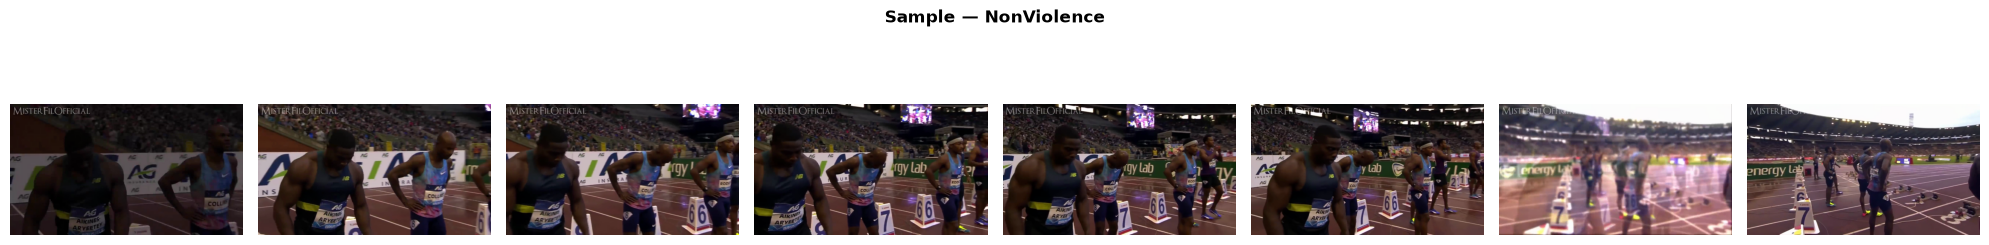

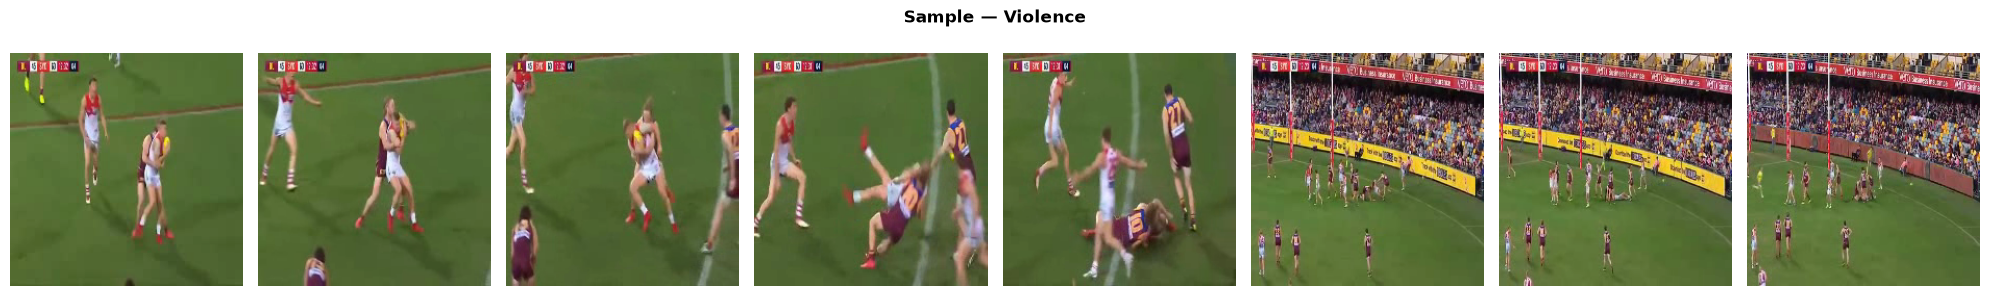

In [6]:
def show_video_frames(video_path: Path, n_frames: int = 8, title: str = ""):
    cap = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = np.linspace(0, total - 1, n_frames, dtype=int)

    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()

    fig, axes = plt.subplots(1, len(frames), figsize=(2.5 * len(frames), 3))
    fig.suptitle(title, fontsize=12, fontweight="bold")
    for ax, frame in zip(axes, frames):
        ax.imshow(frame)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_video_frames(random.choice(nv_videos), title="Sample — NonViolence")
show_video_frames(random.choice(v_videos),  title="Sample — Violence")

## 5. Frame Extraction

In [7]:
def extract_frames(
    video_path: Path,
    sequence_length: int = SEQUENCE_LENGTH,
    img_h: int = IMAGE_HEIGHT,
    img_w: int = IMAGE_WIDTH,
    normalize: bool = True,
) -> np.ndarray | None:
    """
    Uniformly sample `sequence_length` frames from a video.
    Returns array of shape (T, H, W, C) in float32, or None on failure.
    """
    cap = cv2.VideoCapture(str(video_path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames < sequence_length:
        cap.release()
        return None  # video too short

    skip = max(total_frames // sequence_length, 1)
    frames = []

    for i in range(sequence_length):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * skip)
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, (img_w, img_h))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        if normalize:
            frame = frame.astype(np.float32) / 255.0
        frames.append(frame)

    cap.release()

    if len(frames) < sequence_length:
        return None

    return np.array(frames, dtype=np.float32)  # (T, H, W, C)


# Quick sanity check
test_clip = extract_frames(random.choice(nv_videos))
print("Extracted shape:", test_clip.shape)   # expect (16, 64, 64, 3)
print("Value range    :", test_clip.min(), "–", test_clip.max())

Extracted shape: (16, 64, 64, 3)
Value range    : 0.0 – 1.0


## 6. Data Augmentation

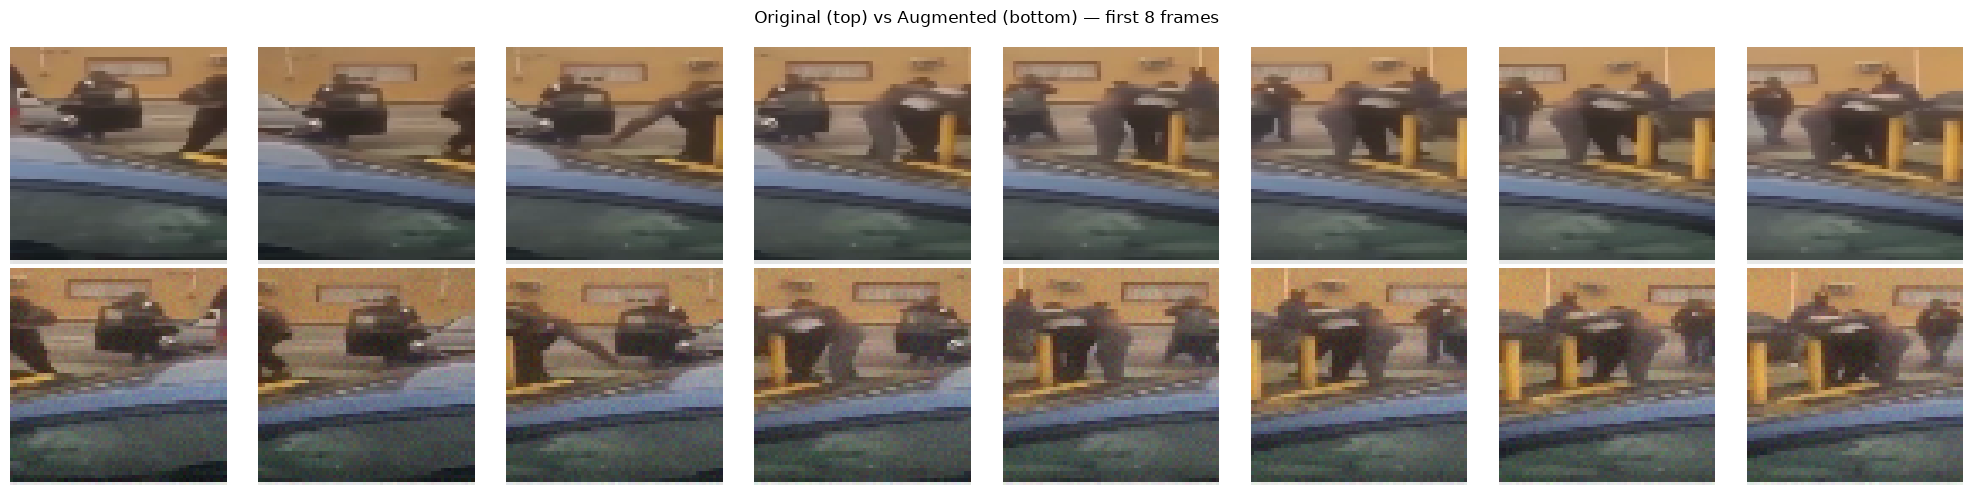

In [8]:
def augment_clip(clip: np.ndarray) -> np.ndarray:
    """
    Apply consistent spatial augmentation to all frames in a clip.
    Input/output shape: (T, H, W, C), values in [0, 1].
    """
    aug = clip.copy()

    # Horizontal flip (50% chance)
    if random.random() < 0.5:
        aug = aug[:, :, ::-1, :].copy()

    # Brightness jitter ±20%
    if random.random() < 0.5:
        factor = random.uniform(0.8, 1.2)
        aug = np.clip(aug * factor, 0.0, 1.0)

    # Random rotation ±15°
    if random.random() < 0.5:
        angle = random.uniform(-15, 15)
        T, H, W, C = aug.shape
        M = cv2.getRotationMatrix2D((W / 2, H / 2), angle, 1.0)
        aug = np.stack(
            [cv2.warpAffine(aug[t], M, (W, H)) for t in range(T)]
        )

    # Gaussian noise (σ ≤ 0.02)
    if random.random() < 0.3:
        noise = np.random.normal(0, 0.02, aug.shape).astype(np.float32)
        aug = np.clip(aug + noise, 0.0, 1.0)

    return aug.astype(np.float32)


# Visualise augmentation effect
original = extract_frames(random.choice(v_videos))
augmented = augment_clip(original)

fig, axes = plt.subplots(2, 8, figsize=(20, 5))
fig.suptitle("Original (top) vs Augmented (bottom) — first 8 frames", fontsize=12)
for i in range(8):
    axes[0, i].imshow(original[i])
    axes[0, i].axis("off")
    axes[1, i].imshow(augmented[i])
    axes[1, i].axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "augmentation_example.png", dpi=120)
plt.show()

## 7. Build Full Dataset

In [9]:
# Set MAX_PER_CLASS = None to use all videos, or an integer to cap the class size.
MAX_PER_CLASS = None
AUGMENT       = True   # create one augmented copy per original clip

def build_dataset(
    video_paths: list[Path],
    label: int,
    augment: bool = False,
    max_clips: int | None = None,
):
    clips, labels, skipped = [], [], 0
    paths = video_paths[:max_clips] if max_clips else video_paths

    for path in tqdm(paths, desc=f"Class {label}"):
        clip = extract_frames(path)
        if clip is None:
            skipped += 1
            continue
        clips.append(clip)
        labels.append(label)
        if augment:
            clips.append(augment_clip(clip))
            labels.append(label)

    print(f"  Loaded {len(paths) - skipped} clips, skipped {skipped} (too short)")
    return clips, labels


print("Processing NonViolence...")
nv_clips, nv_labels = build_dataset(nv_videos, label=0,
                                     augment=AUGMENT, max_clips=MAX_PER_CLASS)

print("Processing Violence...")
v_clips, v_labels   = build_dataset(v_videos,  label=1,
                                     augment=AUGMENT, max_clips=MAX_PER_CLASS)

all_clips  = np.array(nv_clips + v_clips,  dtype=np.float32)  # (N, T, H, W, C)
all_labels = np.array(nv_labels + v_labels, dtype=np.int64)

print(f"\nDataset shape : {all_clips.shape}")
print(f"Labels shape  : {all_labels.shape}")
print(f"Class balance : {np.bincount(all_labels)}")

Processing NonViolence...


Class 0:   0%|          | 0/1000 [00:00<?, ?it/s]

[h264 @ 0x73dfb3100] mb_type 104 in P slice too large at 98 31
[h264 @ 0x73dfb3100] error while decoding MB 98 31
[h264 @ 0x73dfb3100] mb_type 104 in P slice too large at 98 31
[h264 @ 0x73dfb3100] error while decoding MB 98 31
[h264 @ 0x73dfb3100] mb_type 104 in P slice too large at 98 31
[h264 @ 0x73dfb3100] error while decoding MB 98 31
[h264 @ 0x73dfb3100] mb_type 104 in P slice too large at 98 31
[h264 @ 0x73dfb3100] error while decoding MB 98 31


  Loaded 1000 clips, skipped 0 (too short)
Processing Violence...


Class 1:   0%|          | 0/1000 [00:00<?, ?it/s]

  Loaded 1000 clips, skipped 0 (too short)

Dataset shape : (4000, 16, 64, 64, 3)
Labels shape  : (4000,)
Class balance : [2000 2000]


## 8. Train / Validation / Test Split

In [10]:
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9

X_train, X_temp, y_train, y_temp = train_test_split(
    all_clips, all_labels,
    test_size=(1 - TRAIN_RATIO),
    random_state=42,
    stratify=all_labels,
)

val_ratio_of_temp = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=(1 - val_ratio_of_temp),
    random_state=42,
    stratify=y_temp,
)

print(f"Train : {X_train.shape[0]} clips  | {np.bincount(y_train)}")
print(f"Val   : {X_val.shape[0]} clips  | {np.bincount(y_val)}")
print(f"Test  : {X_test.shape[0]} clips  | {np.bincount(y_test)}")

Train : 2799 clips  | [1399 1400]
Val   : 600 clips  | [300 300]
Test  : 601 clips  | [301 300]


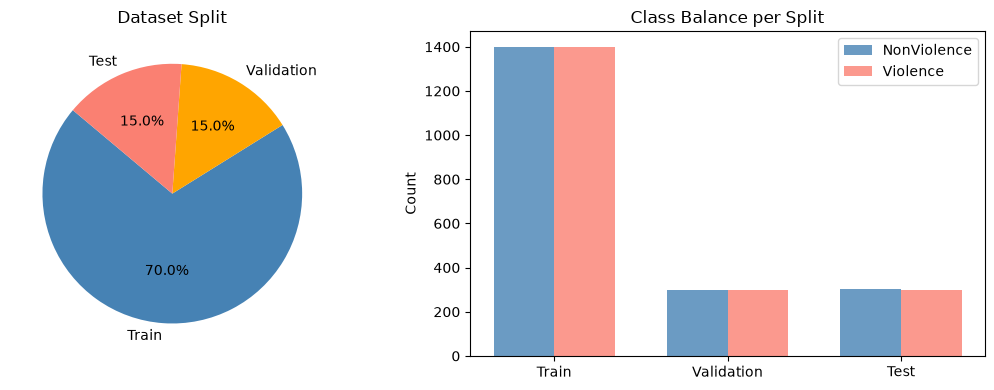

In [11]:
# Split visualisation
split_sizes  = [X_train.shape[0], X_val.shape[0], X_test.shape[0]]
split_labels = ["Train", "Validation", "Test"]
colors       = ["steelblue", "orange", "salmon"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.pie(split_sizes, labels=split_labels, colors=colors,
        autopct="%1.1f%%", startangle=140)
ax1.set_title("Dataset Split")

x     = np.arange(len(split_labels))
width = 0.35
for i, (name, y) in enumerate([("NonViolence", 0), ("Violence", 1)]):
    counts = [np.sum(arr == y) for arr in [y_train, y_val, y_test]]
    ax2.bar(x + i * width, counts, width, label=name,
            color=["steelblue", "salmon"][i], alpha=0.8)
ax2.set_xticks(x + width / 2)
ax2.set_xticklabels(split_labels)
ax2.set_title("Class Balance per Split")
ax2.set_ylabel("Count")
ax2.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "split_distribution.png", dpi=120)
plt.show()

## 9. Pixel Statistics

Per-channel mean (RGB): [0.0915 0.0915 0.0915]
Per-channel std  (RGB): [0.3024 0.2998 0.2992]


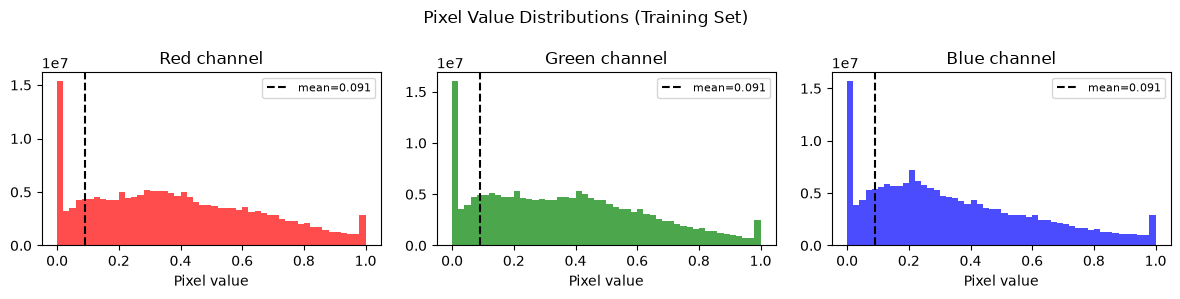

In [12]:
# Compute per-channel mean and std on the training set
# Reshape to (N*T*H*W, C)
flat = X_train.reshape(-1, 3)
channel_mean = flat.mean(axis=0)
channel_std  = flat.std(axis=0)

print("Per-channel mean (RGB):", channel_mean.round(4))
print("Per-channel std  (RGB):", channel_std.round(4))

# Save stats for use in model training
np.save(OUTPUT_DIR / "channel_mean.npy", channel_mean)
np.save(OUTPUT_DIR / "channel_std.npy",  channel_std)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
channel_names = ["Red", "Green", "Blue"]
colors_rgb    = ["red", "green", "blue"]
for i, (ax, name, col) in enumerate(zip(axes, channel_names, colors_rgb)):
    ax.hist(flat[:, i], bins=50, color=col, alpha=0.7)
    ax.axvline(channel_mean[i], color="black", linestyle="--", label=f"mean={channel_mean[i]:.3f}")
    ax.set_title(f"{name} channel")
    ax.set_xlabel("Pixel value")
    ax.legend(fontsize=8)
plt.suptitle("Pixel Value Distributions (Training Set)", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pixel_distributions.png", dpi=120)
plt.show()

## 10. Save Preprocessed Data

In [13]:
splits = {
    "X_train": X_train, "y_train": y_train,
    "X_val"  : X_val,   "y_val"  : y_val,
    "X_test" : X_test,  "y_test" : y_test,
}

for name, array in splits.items():
    out_path = OUTPUT_DIR / f"{name}.npy"
    np.save(out_path, array)
    size_mb = out_path.stat().st_size / 1024 / 1024
    print(f"  {name:10s} → {out_path}  ({size_mb:.1f} MB)")

print("\nAll files saved to:", OUTPUT_DIR.resolve())

  X_train    → preprocessed_data/X_train.npy  (2099.3 MB)
  y_train    → preprocessed_data/y_train.npy  (0.0 MB)
  X_val      → preprocessed_data/X_val.npy  (450.0 MB)
  y_val      → preprocessed_data/y_val.npy  (0.0 MB)
  X_test     → preprocessed_data/X_test.npy  (450.8 MB)
  y_test     → preprocessed_data/y_test.npy  (0.0 MB)

All files saved to: /Users/aliraza/Documents/LSBU/Dissertation/Development/preprocessed_data


## 11. Verify Saved Data

Loaded X_train shape: (2799, 16, 64, 64, 3)
Loaded y_train shape: (2799,)
Value range         : 0.0 – 1.0
Label counts        : [1399 1400]


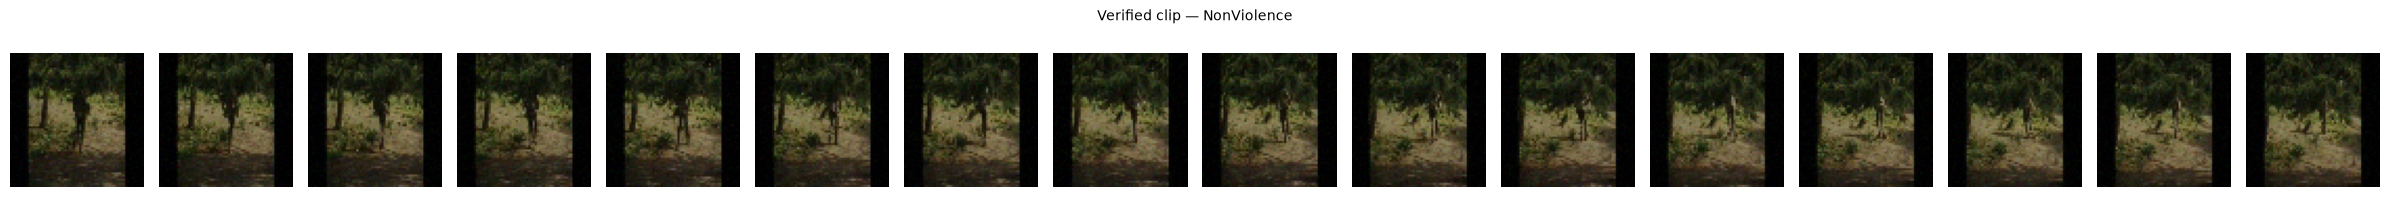

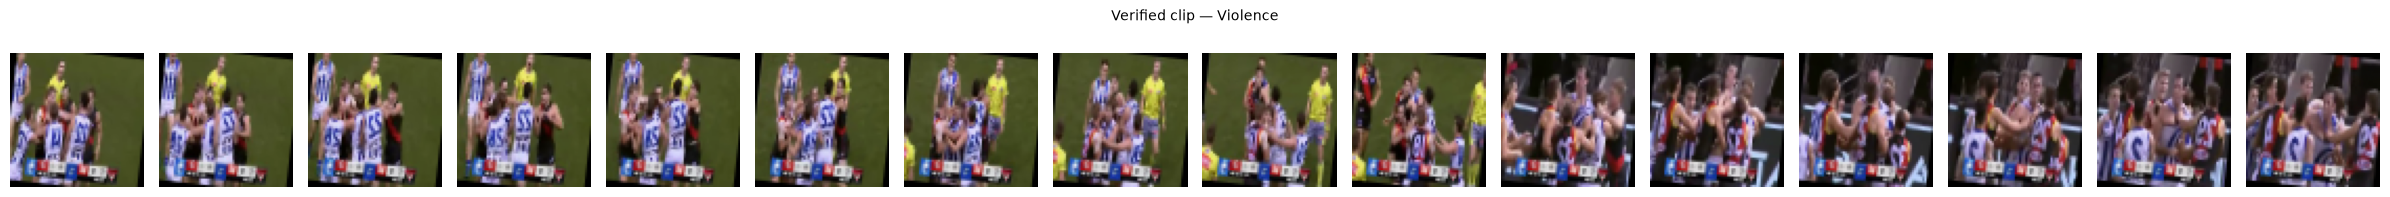


Preprocessing complete — data ready for model training.


In [14]:
X_train_v = np.load(OUTPUT_DIR / "X_train.npy")
y_train_v = np.load(OUTPUT_DIR / "y_train.npy")

print("Loaded X_train shape:", X_train_v.shape)
print("Loaded y_train shape:", y_train_v.shape)
print("Value range         :", X_train_v.min(), "–", X_train_v.max())
print("Label counts        :", np.bincount(y_train_v))

# Spot-check: show first clip from each class
for label, name in enumerate(CLASSES_LIST):
    idx   = np.where(y_train_v == label)[0][0]
    clip  = X_train_v[idx]  # (T, H, W, C)
    fig, axes = plt.subplots(1, SEQUENCE_LENGTH, figsize=(SEQUENCE_LENGTH * 1.5, 2))
    fig.suptitle(f"Verified clip — {name}", fontsize=10)
    for ax, frame in zip(axes, clip):
        ax.imshow(frame)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

print("\nPreprocessing complete — data ready for model training.")